# 5_visualizations

## Project: The "Broken Haven" Hypothesis

This notebook focuses on exploratory data analysis (EDA) and visualization for the Broken Haven project.

The main goal is to examine whether the relationship between gold returns and market stress changed after the COVID-19 period. In particular, this notebook provides descriptive evidence for a possible post-COVID structural shift and prepares charts for the final presentation.

## Section：1 Load and Inspect Data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Data Check：
The cleaned dataset was loaded and sorted by date before visualization.

In [3]:
df = pd.read_csv("final_model_data.csv")
df["DATE"] = pd.to_datetime(df["DATE"])
df = df.sort_values("DATE").reset_index(drop=True)

print("Date range:", df["DATE"].min(), "to", df["DATE"].max())
print("Number of observations:", len(df))

Date range: 2010-10-05 00:00:00 to 2025-09-09 00:00:00
Number of observations: 3894


In [4]:
df["Period"] = np.where(df["is_PostCovid"] == 1, "Post-COVID", "Pre-2022")
df[["DATE", "is_PostCovid", "Period"]].head()

,DATE,is_PostCovid,Period
0,2010-10-05,0,Pre-2022
1,2010-10-06,0,Pre-2022
2,2010-10-07,0,Pre-2022
3,2010-10-08,0,Pre-2022
4,2010-10-11,0,Pre-2022


## Section：2 Time-Series Visualizations

The modelling file defines the post-COVID period using the dummy variable `is_PostCovid`, which equals 1 from January 1, 2022 onward.

This section first creates readable period labels and then visualizes key variables over time.

In [5]:
df["Period"] = np.where(df["is_PostCovid"] == 1, "Post-COVID", "Pre-2022")
df[["DATE", "is_PostCovid", "Period"]].head()

,DATE,is_PostCovid,Period
0,2010-10-05,0,Pre-2022
1,2010-10-06,0,Pre-2022
2,2010-10-07,0,Pre-2022
3,2010-10-08,0,Pre-2022
4,2010-10-11,0,Pre-2022


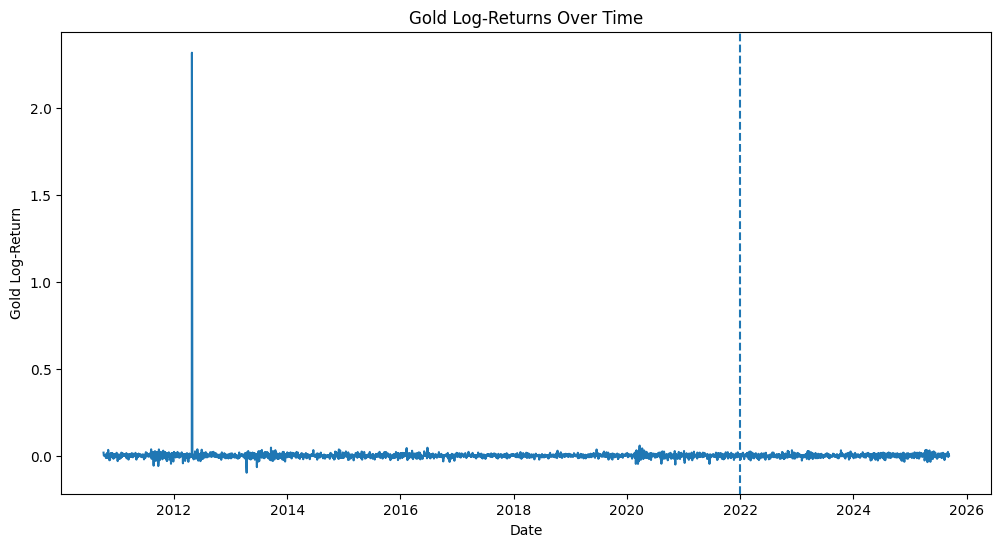

In [6]:
plt.figure(figsize=(12,6))
plt.plot(df["DATE"], df["gold_ret"])
plt.axvline(pd.Timestamp("2022-01-01"), linestyle="--")
plt.title("Gold Log-Returns Over Time")
plt.xlabel("Date")
plt.ylabel("Gold Log-Return")
plt.show()

Gold returns fluctuate over the sample period. The break at January 1, 2022 marks the post-COVID period used in the model and helps visually assess whether return behavior changed after the pandemic period.

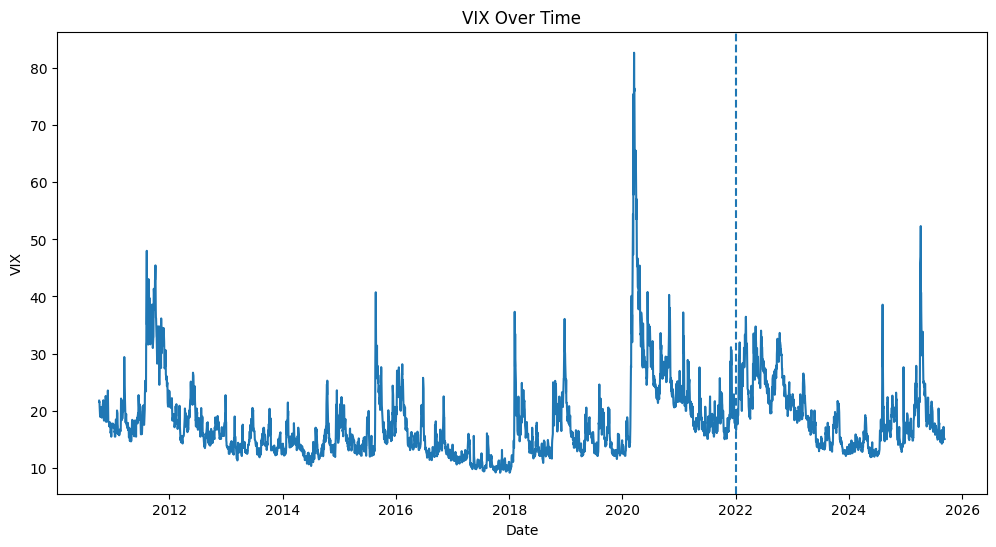

In [7]:
plt.figure(figsize=(12,6))
plt.plot(df["DATE"], df["Close_VIX"])
plt.axvline(pd.Timestamp("2022-01-01"), linestyle="--")
plt.title("VIX Over Time")
plt.xlabel("Date")
plt.ylabel("VIX")
plt.show()

The VIX measures market stress and uncertainty. Since the project tests whether gold retained its safe-haven role, this is one of the most important explanatory variables.

## Section：3 Distribution Comparison by Period

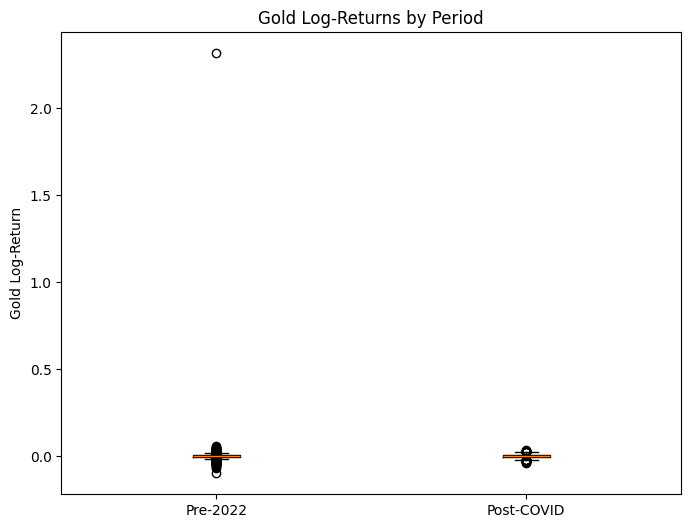

In [8]:
gold_data = [
    df[df["Period"] == "Pre-2022"]["gold_ret"].dropna(),
    df[df["Period"] == "Post-COVID"]["gold_ret"].dropna()
]

plt.figure(figsize=(8,6))
plt.boxplot(gold_data, labels=["Pre-2022", "Post-COVID"])
plt.title("Gold Log-Returns by Period")
plt.ylabel("Gold Log-Return")
plt.show()

This boxplot compares the distribution of gold returns before and after the post-COVID break.  
Differences in spread, outliers, or central tendency may suggest that gold behaved differently across the two periods.

## Section： 4 Key Relationship and Structural Break

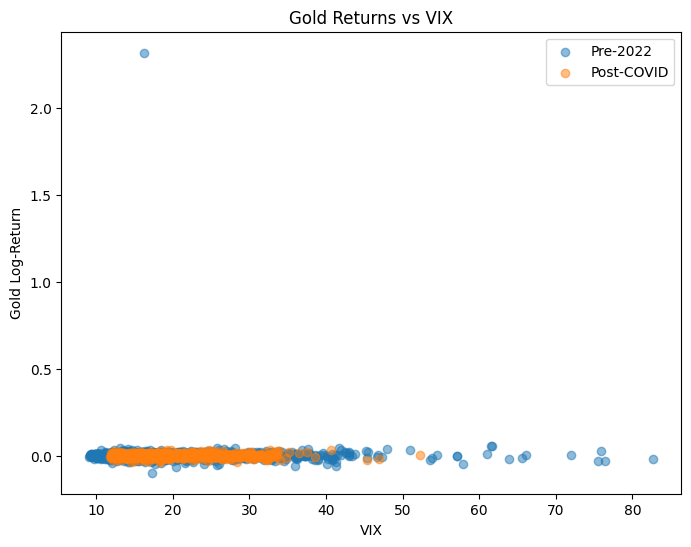

In [10]:
plt.figure(figsize=(8,6))

for period in ["Pre-2022", "Post-COVID"]:
    subset = df[df["Period"] == period]
    plt.scatter(subset["Close_VIX"], subset["gold_ret"], alpha=0.5, label=period)

plt.title("Gold Returns vs VIX")
plt.xlabel("VIX")
plt.ylabel("Gold Log-Return")
plt.legend()
plt.show()

This plot directly relates to the Broken Haven hypothesis. If the relationship between VIX and gold returns appears different across periods, this provides preliminary visual evidence that the safe-haven relationship may have shifted after COVID.

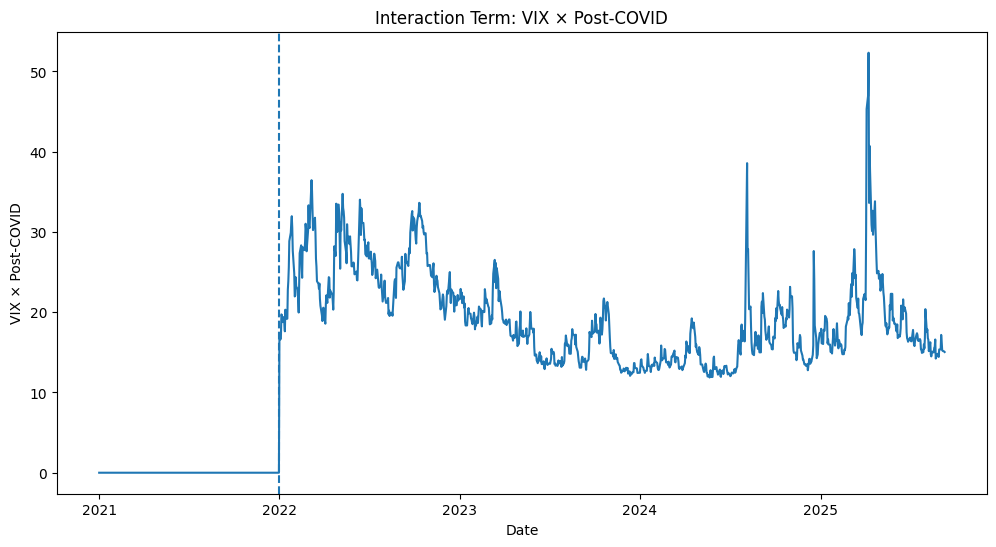

In [13]:
plot_df = df[df["DATE"] >= "2021-01-01"].copy()

plt.figure(figsize=(12,6))
plt.plot(plot_df["DATE"], plot_df["VIX_x_PostCovid"])
plt.axvline(pd.Timestamp("2022-01-01"), linestyle="--")
plt.title("Interaction Term: VIX × Post-COVID")
plt.xlabel("Date")
plt.ylabel("VIX × Post-COVID")
plt.show()

### Interpretation

This figure shows the interaction term `VIX × Post-COVID`, which is constructed to test whether the effect of market stress on gold returns changed after the COVID period. Before January 1, 2022, the variable is equal to zero because the post-COVID dummy is zero. After that date, the interaction term moves together with VIX, reflecting the level of market stress in the post-COVID sample only.

This construction is important because it allows the regression model to estimate whether the relationship between VIX and gold returns became different after the structural break. In other words, the interaction term does not measure general market stress alone, but specifically the post-COVID component of market stress.

## Section 6 Model Results Summary

### 6.1 Lasso Feature Selection Summary

The modelling stage first applied Lasso regression to the candidate predictors in order to reduce multicollinearity and identify the most relevant variables for explaining daily gold returns.

However, under the current specification, the Lasso penalty shrank all coefficients to zero. This suggests that none of the candidate variables showed strong enough predictive power to remain in the model after regularization.

Because of this result, the analysis proceeded with a fallback variable set based on correlation patterns and modelling judgment. The variables passed to the OLS stage were:

- `Close_DX_Y_NYB`
- `wti_crude_oil_price`
- `sp500_ret_lag`
- `VIX_x_PostCovid`

This outcome suggests that daily gold returns may be difficult to predict using these macro-financial variables alone, possibly because gold returns are dominated by short-term noise.

### 6.2 OLS Regression Results

The final interaction model was estimated using OLS with HC3 robust standard errors. The model included the following predictors:

- `Close_DX_Y_NYB`
- `wti_crude_oil_price`
- `sp500_ret_lag`
- `Close_VIX`
- `is_PostCovid`
- `VIX_x_PostCovid`

The main purpose of this specification was to test whether the relationship between market stress and gold returns changed in the post-COVID period.

The regression results show that the interaction term `VIX_x_PostCovid` is not statistically significant. In addition, `Close_VIX` and `is_PostCovid` are also not statistically significant. This means that the model does not provide strong evidence that the effect of VIX on gold returns changed after the post-COVID break.

Among the included variables, `Close_DX_Y_NYB` is the closest to significance, but it still does not reach the 5% significance level. Overall, the model has very low explanatory power, which indicates that the selected predictors explain only a very small share of the variation in daily gold returns.

Therefore, while the descriptive plots may suggest some visual differences across periods, the formal OLS results do not strongly support the Broken Haven hypothesis.
| Variable | Coefficient | p-value | Interpretation |
|----------|-------------|---------|----------------|
| Close_DX_Y_NYB | -0.0001 | 0.063 | Negative but not significant at the 5% level |
| wti_crude_oil_price | -9.458e-07 | 0.979 | No significant relationship |
| sp500_ret_lag | 0.0528 | 0.196 | No significant relationship |
| Close_VIX | 6.826e-06 | 0.892 | No significant relationship |
| is_PostCovid | 0.0021 | 0.174 | No significant shift in average gold returns |
| VIX_x_PostCovid | -2.582e-05 | 0.795 | No significant post-COVID change in the VIX effect |

This project examined whether the relationship between gold returns and market stress changed after the COVID period. The descriptive visualizations suggest that the post-COVID sample differs from the earlier period in several ways, especially in terms of market conditions and the behavior of gold returns.

The modelling results indicate that the relationship is more complex than a simple structural break story. While the visual patterns suggest that gold may not behave in exactly the same way as before, the regression results show that this change is not captured strongly under the current specification. In particular, the key market-stress variables do not provide clear statistical evidence of a sharp post-COVID shift.

Overall, the findings suggest that gold’s safe-haven role may have become less stable or more difficult to explain using a small set of daily macro-financial variables. This makes the Broken Haven hypothesis an interesting and relevant question, while also highlighting that changes in safe-haven behavior may be subtle and require more refined modelling or additional variables to capture fully.